In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END

In [2]:
class AgentState(TypedDict):
    number: int
    counter : int = 0

In [3]:
def initialize_graph(state: AgentState) -> AgentState:
    """Guarantees the internal loop counter starts at 0"""
    state['counter'] = 0
    print(f"number {state['number']}")
    return state

In [4]:
def increase_number(state : AgentState) -> AgentState:
    state['number'] += 1
    state['counter'] += 1
    print(f"Loop : {state['counter']} -- number : {state['number']}")
    return state

In [5]:
def should_continue(state : AgentState) -> AgentState : 
    """Function to decide what to do next"""
    if state['counter']<5  : return "loop"
    else : return "exit"

In [6]:
graph = StateGraph(AgentState)

graph.add_node("initialize_graph",initialize_graph)
graph.add_node("increase_number",increase_number)

graph.add_edge(START,"initialize_graph")
graph.add_edge("initialize_graph","increase_number")

graph.add_conditional_edges(
    "increase_number",
    should_continue,
    {
        "loop":"increase_number",
        "exit" : END
    }
)

app = graph.compile()



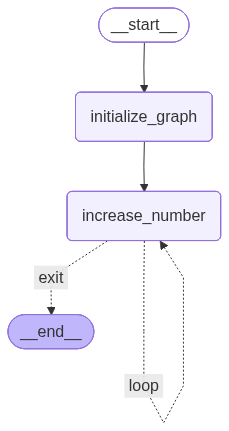

In [7]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
app.invoke(
    {
        'number':2,
        "counter" : -100
    }
)

number 2
Loop : 1 -- number : 3
Loop : 2 -- number : 4
Loop : 3 -- number : 5
Loop : 4 -- number : 6
Loop : 5 -- number : 7


{'number': 7, 'counter': 5}